In [1]:
import numpy as np
import pandas as pd
import random
import math
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split
import shap
import sys

sys.path.insert(0, "../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'

In [3]:
# f = open(f"data/{NUTS0}_WNV_{NUTS2}_cases_dates.txt", "r")
# print(f.read())

In [4]:
r_u = 0.25
near_u = 0.75
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2008, 2010)]
years_to_remove = [2008, 2009]
path = f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2008-2019.csv'

In [5]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,municipality,district,region,municipality_enc,area,pop_1,pop_2,pop_3,pop_total,eq_distance,day,month,week,year,season,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,season_sin,season_cos,mosq_pred,mosq_prev_30d,case_prev_p,case_prev_m,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,hot_days_prev_30d,hot_days_from_newyear,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,case
0,12.02992,45.06869,2010-06-01,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,1,6,22,2010,3,0.201299,0.979530,1.224647e-16,-1.000000,4.647232e-01,-0.885456,-1.0,-1.836970e-16,357,2,0,0,0.377443,0.116895,-0.230719,-0.116895,0.378023,0.113023,-0.235218,-0.113023,0.059966,0.04221,0.056778,0.04221,20.778333,29.033333,12.523333,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,18.900000,19.233333,440.966667,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
1,12.02992,45.06869,2010-06-16,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,16,6,24,2010,3,-0.101168,-0.994869,1.224647e-16,-1.000000,2.393157e-01,-0.970942,-1.0,-1.836970e-16,310,358,0,0,0.377443,0.116895,-0.230719,-0.116895,0.378023,0.113023,-0.235218,-0.113023,0.059966,0.04221,0.056778,0.04221,24.920000,31.536667,18.303333,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,53.033333,59.100000,500.066667,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
2,12.02992,45.06869,2010-07-01,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,1,7,26,2010,3,0.201299,0.979530,-5.000000e-01,-0.866025,-3.216245e-16,-1.000000,-1.0,-1.836970e-16,654,667,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.861667,29.756667,17.966667,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,2.800000,76.133333,576.200000,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
3,12.02992,45.06869,2010-07-16,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,16,7,28,2010,3,-0.101168,-0.994869,-5.000000e-01,-0.866025,-2.393157e-01,-0.970942,-1.0,-1.836970e-16,301,964,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.560000,35.130000,23.990000,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,0.600000,52.033333,628.233333,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
4,12.02992,45.06869,2010-08-01,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,1,8,30,2010,3,0.201299,0.979530,-8.660254e-01,-0.500000,-4.647232e-01,-0.885456,-1.0,-1.836970e-16,400,955,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.665000,32.036667,17.293333,3.274155,-1.849167,7.065606,-0.166651,14.399683,2.00628,23.636976,8.028204,0,0,3.900000,10.966667,639.200000,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0


In [6]:
dataset.drop(columns=['season', 'season_sin', 'season_cos'], inplace=True)

In [7]:
# dataset = dataset.query('month >= 6 & month <= 10')
# dataset.reset_index(inplace=True, drop=True)

dataset.rename(columns={"municipality": "lau1", "district": "nuts3", "region" : "nuts2", "municipality_enc" : "lau1_id"}, inplace=True)

In [8]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,1901,7,1908,9.99%
1,2011,1897,11,1908,9.99%
2,2012,1877,34,1911,10.00%
3,2013,1880,29,1909,9.99%
4,2014,1906,2,1908,9.99%
5,2015,1907,1,1908,9.99%
6,2016,1896,12,1908,9.99%
7,2017,1892,17,1909,9.99%
8,2018,1791,134,1925,10.08%
9,2019,1873,37,1910,10.00%


In [9]:
X_train = dataset.select_dtypes(exclude=['object']).drop(columns = ['case'])
y_train = dataset['case']

features = X_train.columns

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)

imputer = KNNImputer()
X_train = imputer.fit_transform(X_train)

try:
    class_0_counts = y_train.value_counts()[0]
except KeyError:
    class_0_counts = 0
try:
    class_1_counts = y_train.value_counts()[1]
except KeyError:
    class_1_counts = 0
        
if (near_u != 0):
    nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
    X_train, y_train = nm.fit_resample(X_train, y_train)
    
if (smote != 0):
    class_0_counts = y_train.value_counts()[0]
    sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
    X_train, y_train = sm.fit_resample(X_train, y_train)

w0,w1 = calculate_weights(y_train)

model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
model.fit(X_train, y_train)

masker = shap.maskers.Independent(data = X_train)
explainer = shap.LinearExplainer(model, masker = masker)
shap_values = explainer.shap_values(X_train)

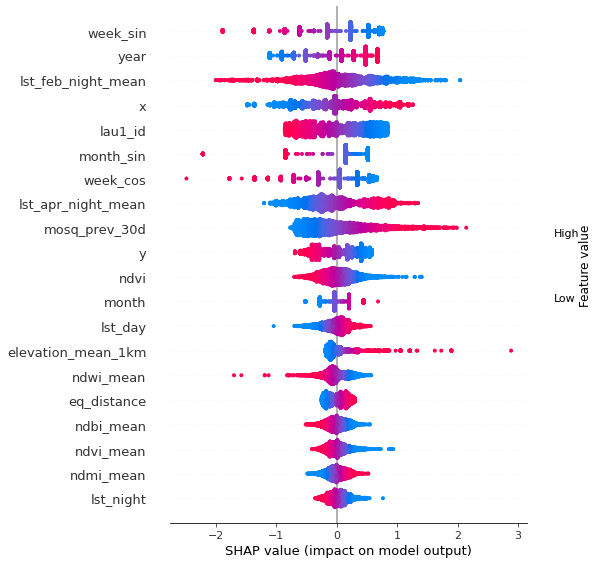

In [10]:
shap.summary_plot(shap_values, features = X_train, feature_names = features)

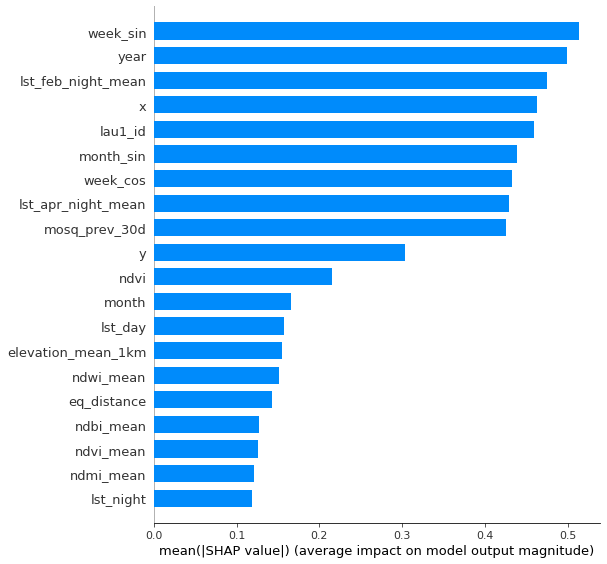

In [11]:
shap.summary_plot(shap_values, features = X_train, feature_names = features, plot_type='bar')

In [12]:
mean_shap_values = shap_values.mean(axis=0)

In [13]:
ft_importance = pd.DataFrame()

for i in range(len(features)):
    ft_importance = ft_importance.append({'Feature': features[i],
                                          'Shap': mean_shap_values[i]}, ignore_index = True)

In [14]:
ft_importance.sort_values(by='Shap', key=pd.Series.abs, inplace = True, ascending = False)

In [15]:
ft_importance

,Feature,Shap
17,week_sin,0.066614
41,lst_feb_night_mean,0.061597
45,lst_apr_night_mean,-0.038481
18,week_cos,-0.037670
0,x,-0.034077
15,month_sin,0.033878
12,year,-0.029896
23,ndvi,0.029536
55,elevation_mean_1km,0.028863
21,case_prev_p,0.026597


In [16]:
mean_shap = ft_importance['Shap']
shp = mean_shap.shape[0]
mean_shap = mean_shap.to_numpy().reshape(1,shp)

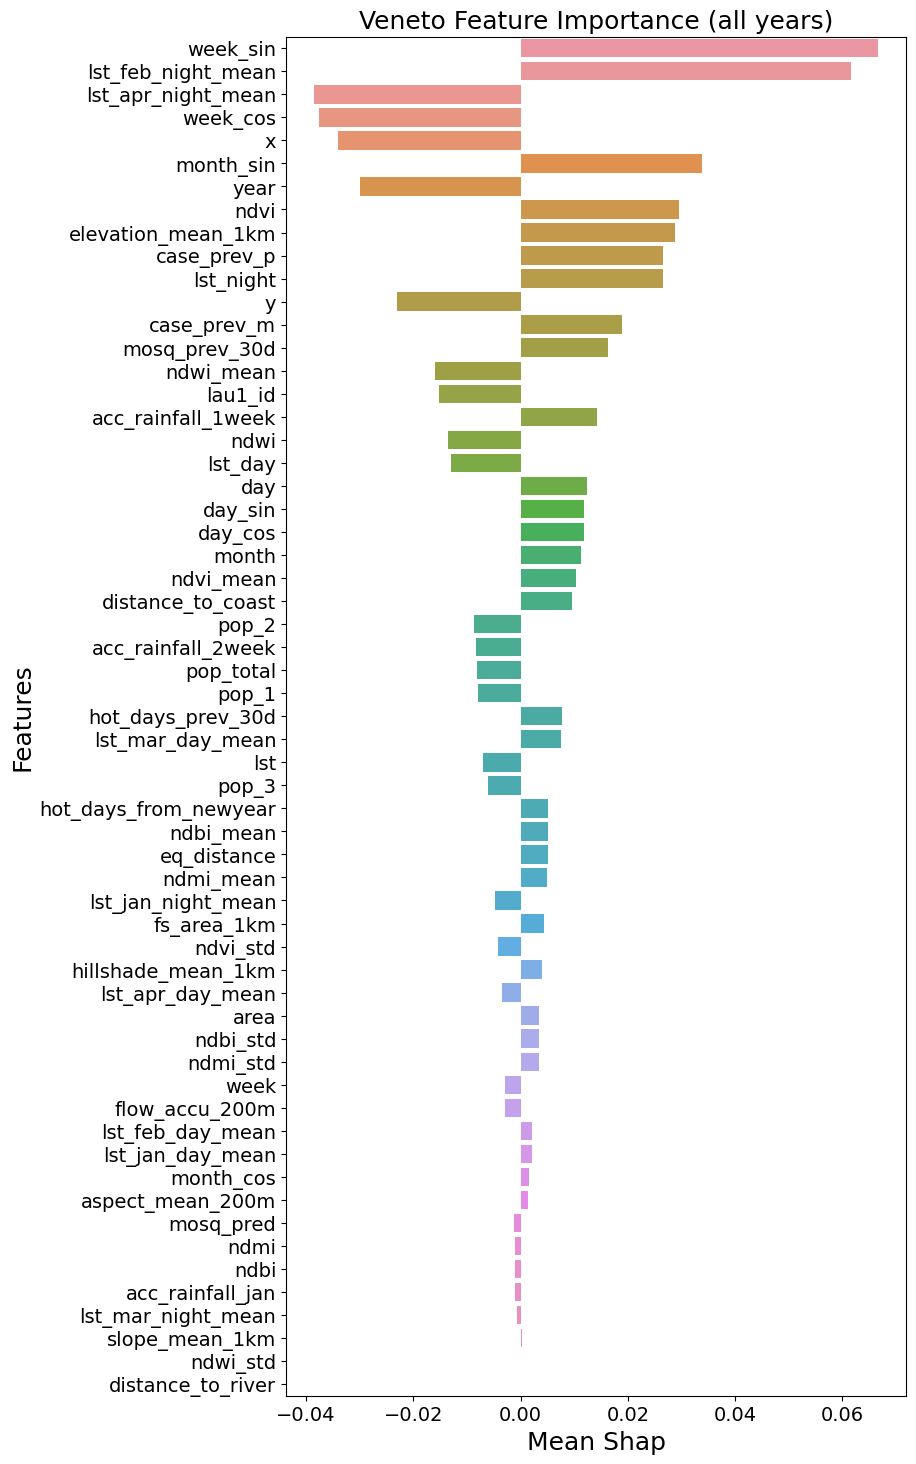

In [17]:
plot_feature_importance(mean_shap, ft_importance['Feature'], x_label = 'Mean Shap', title = f'{NUTS2} Feature Importance (all years)', title_size=18)

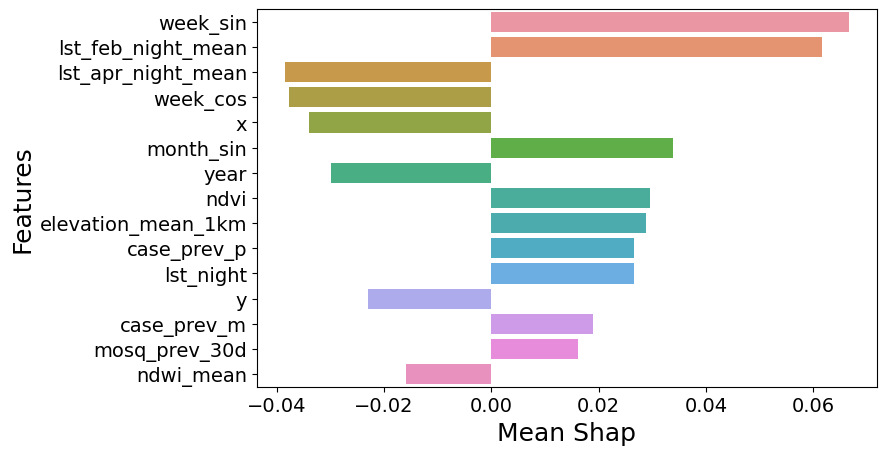

In [18]:
plot_feature_importance(mean_shap, ft_importance['Feature'], top=15, x_label = 'Mean Shap', figure_size=(8,5))